# Task 2: Multi-class Classification on Fashion-MNIST with FCNN + Optimizer Comparison



In [27]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import TensorDataset, DataLoader

import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# Same random values every time
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


## 1. Load Fashion-MNIST

In [28]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Official train samples:", len(train_dataset))
print("Official test samples:", len(test_dataset))

Official train samples: 60000
Official test samples: 10000


## 2. Select 5 classes and build the required 64/16/20 split


In [29]:
FASHION_MNIST_CLASSES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

selected_classes = [1, 5, 7, 8, 9]
class_names = [FASHION_MNIST_CLASSES[c] for c in selected_classes]
print("Selected classes:", class_names)

X_all = np.concatenate([train_dataset.data.numpy(), test_dataset.data.numpy()], axis=0)
y_all = np.concatenate([train_dataset.targets.numpy(), test_dataset.targets.numpy()], axis=0)

mask = np.isin(y_all, selected_classes)
X = X_all[mask]
y = y_all[mask]

label_map = {old_label: new_label for new_label, old_label in enumerate(selected_classes)}
y = np.array([label_map[label] for label in y])

print("Total selected samples (5 classes, train+test merged):", len(X))
print("Classes present:", np.unique(y))

Selected classes: ['Trouser', 'Sandal', 'Sneaker', 'Bag', 'Ankle boot']
Total selected samples (5 classes, train+test merged): 35000
Classes present: [0 1 2 3 4]


In [30]:

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.20,
    random_state=SEED,
    stratify=y_trainval
)

n_total = len(X)
print(f"Train:      {len(X_train):6d}  ({100 * len(X_train) / n_total:.1f}% of total)")
print(f"Validation: {len(X_val):6d}  ({100 * len(X_val) / n_total:.1f}% of total)")
print(f"Test:       {len(X_test):6d}  ({100 * len(X_test) / n_total:.1f}% of total)")

Train:       22400  (64.0% of total)
Validation:   5600  (16.0% of total)
Test:         7000  (20.0% of total)


In [31]:

X_train = X_train.astype(np.float32) / 255.0
X_val   = X_val.astype(np.float32) / 255.0
X_test  = X_test.astype(np.float32) / 255.0

X_train = X_train.reshape(-1, 784)
X_val   = X_val.reshape(-1, 784)
X_test  = X_test.reshape(-1, 784)

# Convert NumPy arrays to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

print(X_train.shape, X_val.shape, X_test.shape)

torch.Size([22400, 784]) torch.Size([5600, 784]) torch.Size([7000, 784])


In [32]:
train_data = TensorDataset(X_train, y_train)
val_data   = TensorDataset(X_val, y_val)
test_data  = TensorDataset(X_test, y_test)

print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

Train: 22400
Validation: 5600
Test: 7000


## 3. Model definition (FCNN)

In [33]:
class FCNN(nn.Module):

    def __init__(self, input_size, hidden_layers, output_size=5):
        super().__init__()

        layers = []

        # First hidden layer
        layers.append(nn.Linear(input_size, hidden_layers[0]))
        layers.append(nn.ReLU())

        # Remaining hidden layers
        for i in range(1, len(hidden_layers)):
            layers.append(
                nn.Linear(hidden_layers[i - 1], hidden_layers[i])
            )
            layers.append(nn.ReLU())

        # Output layer
        layers.append(nn.Linear(hidden_layers[-1], output_size))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

## 4. Architectures to compare


In [34]:
architectures = {
    "Arch-A (3 layers)": [128, 64, 32],
    "Arch-B (4 layers)": [256, 128, 64, 32],
    "Arch-C (5 layers)": [256, 128, 64, 32, 16]
    # "Arch-D (6 layers)": [256, 128, 64, 32, 16, 8],
    # "Arch-E (6 layers)": [512,256, 128, 64, 32, 16],
}

for name, layers in architectures.items():
    print(name, "->", layers)

Arch-A (3 layers) -> [128, 64, 32]
Arch-B (4 layers) -> [256, 128, 64, 32]
Arch-C (5 layers) -> [256, 128, 64, 32, 16]


## 5. Optimizers

In [35]:
def get_optimizer(model, name):

    lr = {"SGD": 0.01, "Batch GD": 0.1, "Momentum": 0.01,
          "NAG": 0.01, "RMSProp": 0.001, "Adam": 0.001}[name]
    wd = 1e-4

    if name in ("SGD", "Batch GD"):
        return optim.SGD(model.parameters(), lr=lr, weight_decay=wd)
    elif name == "Momentum":
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=wd)
    elif name == "NAG":
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True, weight_decay=wd)
    elif name == "RMSProp":
        return optim.RMSprop(model.parameters(), lr=lr, alpha=0.99, eps=1e-8, weight_decay=wd)
    elif name == "Adam":
        return optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.999), eps=1e-8, weight_decay=wd)
    else:
        raise ValueError(f"Unknown optimizer name: {name}")

optimizer_names = ["SGD", "Batch GD", "Momentum", "NAG", "RMSProp", "Adam"]

## 6. Data loaders

Assignment: batch_size = 1 for SGD, Momentum, NAG, RMSProp and Adam; batch_size = total number of
training examples for Batch (vanilla) Gradient Descent.

**FIX:** the original `get_train_loader` referenced the global `train_data` variable directly. It now
takes the dataset as a parameter so it can be reused for any dataset/subset.

In [36]:
# def get_train_loader(dataset, optimizer_name):

#     if optimizer_name == "Batch GD":
#         batch_size = len(dataset)
#     else:
#         batch_size = 1

#     return DataLoader(
#         dataset,
#         batch_size=batch_size,
#         shuffle=True
#     )


val_loader = DataLoader(val_data, batch_size=256, shuffle=False)
test_loader = DataLoader(test_data, batch_size=256, shuffle=False)
eval_train_loader = DataLoader(train_data, batch_size=256, shuffle=False)  # for measuring train accuracy

## 8. Run the full experiment: every architecture x every optimizer

**FIX (requirement e):** for each architecture, one base model is created and its initial weights are
snapshotted with `state_dict()`. Before training with *each* optimizer, a fresh model is built and loaded
with that same snapshot, so all 6 optimizers for a given architecture start from identical weights.

**Runtime note:** batch_size = 1 ("SGD", "Momentum", "NAG", "RMSProp", "Adam") means one epoch performs
~19,200 individual weight updates (size of the 64% training split), which is inherently slow in PyTorch's
Python loop. Set `QUICK_TEST = True` below to subsample the data for a fast dry run while you're checking
the notebook runs end-to-end, then set it back to `False` (using the full data) for your real, submitted
results. `MAX_EPOCHS` is a safety cap on top of the error-difference stopping rule in requirement (f).

In [37]:
import os, copy
from google.colab import drive
from joblib import Parallel, delayed

drive.mount('/content/drive')
SAVE_DIR = "/content/drive/MyDrive/assg3_task2_results_exp2"   # NEW folder, old results would be skipped otherwise
os.makedirs(SAVE_DIR, exist_ok=True)

THRESHOLD = 1e-4
BATCH_SIZE = 16
MAX_EPOCHS = 100
BATCH_GD_MAX_EPOCHS = 5000


def arch_key(arch_name):
    return arch_name.split(" ")[0]


def safe_save(obj, path):
    tmp = path + ".tmp"
    torch.save(obj, tmp)
    os.replace(tmp, path)


def get_initial_state(arch_name):
    path = f"{SAVE_DIR}/init_{arch_key(arch_name)}.pt"
    if os.path.exists(path):
        return torch.load(path, weights_only=False)
    state = copy.deepcopy(FCNN(784, architectures[arch_name], 5).state_dict())
    safe_save(state, path)
    return state


# def run_one(arch_name, hidden_layers, opt_name, initial_state,
#             X_tr, y_tr, X_va, y_va, save_dir, max_epochs, threshold, seed,
#             batch_size, patience, min_gain):
#     torch.set_num_threads(1)
#     torch.manual_seed(seed)

#     key = f"{arch_key(arch_name)}_{opt_name.replace(' ', '')}"
#     result_path = f"{save_dir}/result_{key}.pt"
#     ckpt_path = f"{save_dir}/ckpt_{key}.pt"

#     if os.path.exists(result_path):
#         return f"{key}: already finished, skipped"

#     model = FCNN(784, hidden_layers, 5)
#     model.load_state_dict(initial_state)                   # requirement (e)
#     optimizer = get_optimizer(model, opt_name)
#     criterion = nn.CrossEntropyLoss()

#     errors, val_accs, start_epoch = [], [], 0
#     best_val, best_state = -1.0, None

#     if os.path.exists(ckpt_path):                          # resume after a disconnect
#         ck = torch.load(ckpt_path, weights_only=False)
#         model.load_state_dict(ck["model"])
#         optimizer.load_state_dict(ck["optimizer"])
#         errors, val_accs = ck["errors"], ck["val_accs"]
#         best_val, best_state = ck["best_val"], ck["best_state"]
#         start_epoch = max_epochs if ck["done"] else ck["epoch"]

#     n = len(X_tr)
#     bs = n if opt_name == "Batch GD" else batch_size

#     def acc(X, y):
#         model.eval()
#         with torch.no_grad():
#             preds = torch.cat([model(X[i:i+4096]).argmax(1) for i in range(0, len(X), 4096)])
#         return 100 * (preds == y).float().mean().item()

#     for epoch in range(start_epoch, max_epochs):
#         model.train()
#         perm = torch.randperm(n)
#         Xs, ys = X_tr[perm], y_tr[perm]
#         total = 0.0
#         for i in range(0, n, bs):
#             xb, yb = Xs[i:i+bs], ys[i:i+bs]
#             loss = criterion(model(xb), yb)
#             optimizer.zero_grad(set_to_none=True)
#             loss.backward()
#             optimizer.step()
#             total += loss.item() * len(xb)

#         errors.append(total / n)
#         val_accs.append(acc(X_va, y_va))

#         if val_accs[-1] > best_val:                        # keep best-validation weights
#             best_val, best_state = val_accs[-1], copy.deepcopy(model.state_dict())

#         converged = len(errors) > 1 and abs(errors[-2] - errors[-1]) < threshold   # requirement (f)
#         stalled = (opt_name != "Batch GD" and len(val_accs) > patience and
#                    max(val_accs[-patience:]) < max(val_accs[:-patience]) + min_gain)
#         done = converged or stalled or (epoch == max_epochs - 1)

#         safe_save({"model": model.state_dict(), "optimizer": optimizer.state_dict(),
#                    "errors": errors, "val_accs": val_accs,
#                    "best_val": best_val, "best_state": best_state,
#                    "epoch": epoch + 1, "done": done}, ckpt_path)
#         if done:
#             break

#     model.load_state_dict(best_state)                      # final model = best validation epoch

#     safe_save({
#         "epoch_errors": errors,
#         "val_accuracies": val_accs,
#         "epochs_to_converge": len(errors),
#         "train_accuracy": acc(X_tr, y_tr),
#         "val_accuracy": best_val,
#         "state": copy.deepcopy(model.state_dict()),
#     }, result_path)

#     if os.path.exists(ckpt_path):
#         os.remove(ckpt_path)
#     return f"{key}: stopped after {len(errors)} epochs, best val {best_val:.2f}%"
def run_one(arch_name, hidden_layers, opt_name, initial_state,
            X_tr, y_tr, X_va, y_va, save_dir, threshold, seed, batch_size):
    torch.set_num_threads(1)
    torch.manual_seed(seed)

    key = f"{arch_key(arch_name)}_{opt_name.replace(' ', '')}"
    result_path = f"{save_dir}/result_{key}.pt"
    ckpt_path = f"{save_dir}/ckpt_{key}.pt"

    if os.path.exists(result_path):
        return f"{key}: already finished, skipped"

    model = FCNN(784, hidden_layers, 5)
    model.load_state_dict(initial_state)                   # requirement (e)
    optimizer = get_optimizer(model, opt_name)
    criterion = nn.CrossEntropyLoss()

    is_batch_gd = (opt_name == "Batch GD")
    max_epochs = BATCH_GD_MAX_EPOCHS if is_batch_gd else MAX_EPOCHS
    n = len(X_tr)
    bs = n if is_batch_gd else batch_size                  # Batch GD: full batch

    errors, val_accs, start_epoch, stop_reason = [], [], 0, None

    if os.path.exists(ckpt_path):                          # resume after a disconnect
        ck = torch.load(ckpt_path, weights_only=False)
        model.load_state_dict(ck["model"])
        optimizer.load_state_dict(ck["optimizer"])
        errors, val_accs = ck["errors"], ck["val_accs"]
        stop_reason = ck["stop_reason"]
        start_epoch = max_epochs if ck["done"] else ck["epoch"]

    def acc(X, y):
        model.eval()
        with torch.no_grad():
            preds = torch.cat([model(X[i:i+4096]).argmax(1) for i in range(0, len(X), 4096)])
        return 100 * (preds == y).float().mean().item()

    for epoch in range(start_epoch, max_epochs):
        model.train()
        perm = torch.randperm(n)
        Xs, ys = X_tr[perm], y_tr[perm]
        total = 0.0
        for i in range(0, n, bs):
            xb, yb = Xs[i:i+bs], ys[i:i+bs]
            loss = criterion(model(xb), yb)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            total += loss.item() * len(xb)

        errors.append(total / n)
        val_accs.append(acc(X_va, y_va))

        # requirement (f): the ONLY stopping rule (max-epochs is just a safety cap)
        if len(errors) > 1 and abs(errors[-2] - errors[-1]) < threshold:
            stop_reason = "converged"
        elif epoch == max_epochs - 1:
            stop_reason = "max-epochs"
        done = stop_reason is not None

        if done or (epoch + 1) % 10 == 0:                  # checkpoint every 10 epochs (and at the end)
            safe_save({"model": model.state_dict(), "optimizer": optimizer.state_dict(),
                       "errors": errors, "val_accs": val_accs,
                       "epoch": epoch + 1, "done": done, "stop_reason": stop_reason}, ckpt_path)
        if done:
            break

    # final model = weights at the epoch where training stopped (no best-validation restore)
    safe_save({
        "epoch_errors": errors,
        "val_accuracies": val_accs,
        "epochs_to_converge": len(errors),
        "stop_reason": stop_reason,
        "train_accuracy": acc(X_tr, y_tr),
        "val_accuracy": acc(X_va, y_va),
        "state": copy.deepcopy(model.state_dict()),
    }, result_path)

    if os.path.exists(ckpt_path):
        os.remove(ckpt_path)
    return f"{key}: {stop_reason} after {len(errors)} epochs, val {acc(X_va, y_va):.2f}%"


# def run_architecture(arch_name):
#     init_state = get_initial_state(arch_name)
#     n_jobs = min(len(optimizer_names), os.cpu_count())
#     print(f"{arch_name}: running {len(optimizer_names)} optimizers on {n_jobs} cores")
#     msgs = Parallel(n_jobs=n_jobs, verbose=10)(
#         delayed(run_one)(arch_name, architectures[arch_name], o, init_state,
#                          X_train, y_train, X_val, y_val,
#                          SAVE_DIR, MAX_EPOCHS, THRESHOLD, SEED,
#                          BATCH_SIZE, PATIENCE, MIN_GAIN)
#         for o in optimizer_names
#     )
#     print("\n".join(msgs))
def run_architecture(arch_name):
    init_state = get_initial_state(arch_name)
    n_jobs = min(len(optimizer_names), os.cpu_count())
    print(f"{arch_name}: running {len(optimizer_names)} optimizers on {n_jobs} cores")
    msgs = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(run_one)(arch_name, architectures[arch_name], o, init_state,
                         X_train, y_train, X_val, y_val,
                         SAVE_DIR, THRESHOLD, SEED, BATCH_SIZE)
        for o in optimizer_names
    )
    print("\n".join(msgs))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
run_architecture("Arch-A (3 layers)")

Arch-A (3 layers): running 6 optimizers on 2 cores


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   1 tasks      | elapsed:    2.9s
[Parallel(n_jobs=2)]: Done   4 out of   6 | elapsed:    3.7s remaining:    1.8s


Arch-A_SGD: already finished, skipped
Arch-A_BatchGD: already finished, skipped
Arch-A_Momentum: already finished, skipped
Arch-A_NAG: already finished, skipped
Arch-A_RMSProp: already finished, skipped
Arch-A_Adam: already finished, skipped


[Parallel(n_jobs=2)]: Done   6 out of   6 | elapsed:    4.3s finished


In [39]:
run_architecture("Arch-B (4 layers)")

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


Arch-B (4 layers): running 6 optimizers on 2 cores


[Parallel(n_jobs=2)]: Done   1 tasks      | elapsed:    0.5s
[Parallel(n_jobs=2)]: Done   4 out of   6 | elapsed:    1.4s remaining:    0.7s


Arch-B_SGD: already finished, skipped
Arch-B_BatchGD: already finished, skipped
Arch-B_Momentum: already finished, skipped
Arch-B_NAG: already finished, skipped
Arch-B_RMSProp: already finished, skipped
Arch-B_Adam: already finished, skipped


[Parallel(n_jobs=2)]: Done   6 out of   6 | elapsed:    2.0s finished


In [40]:
run_architecture("Arch-C (5 layers)")

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


Arch-C (5 layers): running 6 optimizers on 2 cores


[Parallel(n_jobs=2)]: Done   1 tasks      | elapsed:    0.4s
[Parallel(n_jobs=2)]: Done   4 out of   6 | elapsed:    1.4s remaining:    0.7s


Arch-C_SGD: already finished, skipped
Arch-C_BatchGD: already finished, skipped
Arch-C_Momentum: already finished, skipped
Arch-C_NAG: already finished, skipped
Arch-C_RMSProp: already finished, skipped
Arch-C_Adam: already finished, skipped


[Parallel(n_jobs=2)]: Done   6 out of   6 | elapsed:    2.0s finished


In [41]:
# run_architecture("Arch-D (6 layers)")

In [42]:
# run_architecture("Arch-E (6 layers)")

In [43]:
results, trained_states, missing = {}, {}, []

for arch_name in architectures:
    results[arch_name], trained_states[arch_name] = {}, {}
    for opt_name in optimizer_names:
        path = f"{SAVE_DIR}/result_{arch_key(arch_name)}_{opt_name.replace(' ', '')}.pt"
        if not os.path.exists(path):
            missing.append((arch_name, opt_name))
            continue
        r = torch.load(path, weights_only=False)
        trained_states[arch_name][opt_name] = r.pop("state")
        results[arch_name][opt_name] = r

if missing:
    raise RuntimeError(f"These runs are not finished yet: {missing}")
print("All 18 runs loaded.")

All 18 runs loaded.


## 9. Results table: epochs to convergence, training and validation accuracy

In [44]:
rows = []
for arch_name in architectures:
    for opt_name in optimizer_names:
        r = results[arch_name][opt_name]
        # rows.append({
        #     "Architecture": arch_name,
        #     "Optimizer": opt_name,
        #     "Epochs to Converge": r["epochs_to_converge"],
        #     "Train Accuracy (%)": round(r["train_accuracy"], 2),
        #     "Val Accuracy (%)": round(r["val_accuracy"], 2),
        # })
        rows.append({
              "Architecture": arch_name,
              "Optimizer": opt_name,
              "Epochs to Converge": r["epochs_to_converge"],
              "Stop reason": r["stop_reason"],
              "Train Accuracy (%)": round(r["train_accuracy"], 2),
              "Val Accuracy (%)": round(r["val_accuracy"], 2),
        })

results_df = pd.DataFrame(rows)
results_df

,Architecture,Optimizer,Epochs to Converge,Stop reason,Train Accuracy (%),Val Accuracy (%)
0,Arch-A (3 layers),SGD,100,max-epochs,99.97,96.77
1,Arch-A (3 layers),Batch GD,93,converged,82.41,82.20
2,Arch-A (3 layers),Momentum,49,converged,99.40,97.07
3,Arch-A (3 layers),NAG,36,converged,98.88,96.46
4,Arch-A (3 layers),RMSProp,55,converged,97.41,94.95
5,Arch-A (3 layers),Adam,20,converged,98.69,96.55
6,Arch-B (4 layers),SGD,26,converged,98.78,96.48
7,Arch-B (4 layers),Batch GD,344,converged,93.48,93.04
8,Arch-B (4 layers),Momentum,27,converged,99.27,97.09
9,Arch-B (4 layers),NAG,27,converged,99.34,97.23


## 10. Training error vs. epoch, superimposed across optimizers (per architecture)

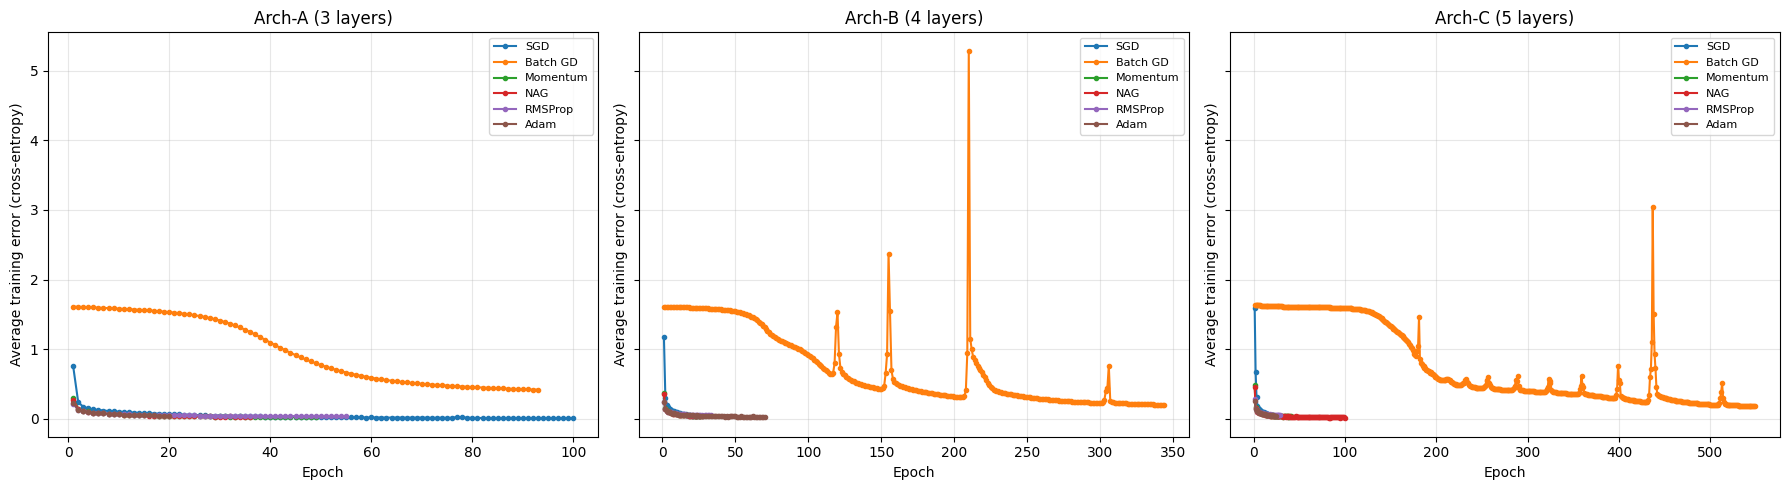

In [45]:
fig, axes = plt.subplots(1, len(architectures), figsize=(6 * len(architectures), 5), sharey=True)

if len(architectures) == 1:
    axes = [axes]

for ax, (arch_name, hidden_layers) in zip(axes, architectures.items()):
    for opt_name in optimizer_names:
        errors = results[arch_name][opt_name]["epoch_errors"]
        ax.plot(range(1, len(errors) + 1), errors, marker="o", markersize=3, label=opt_name)
    ax.set_title(arch_name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Average training error (cross-entropy)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

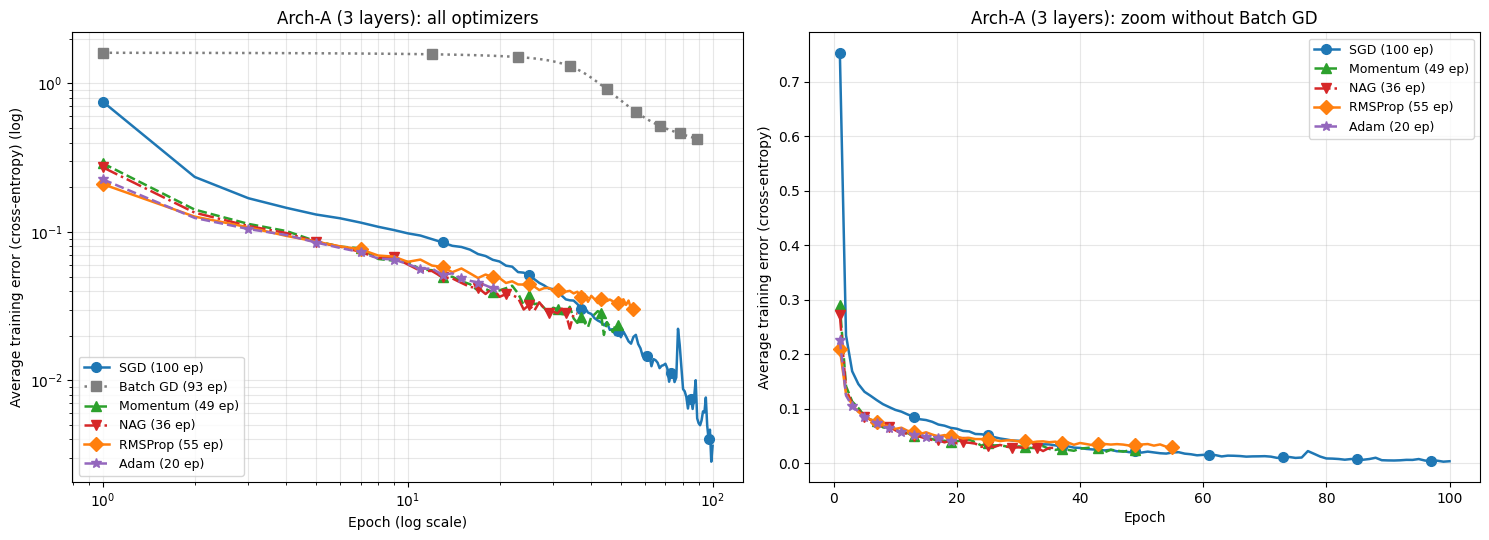

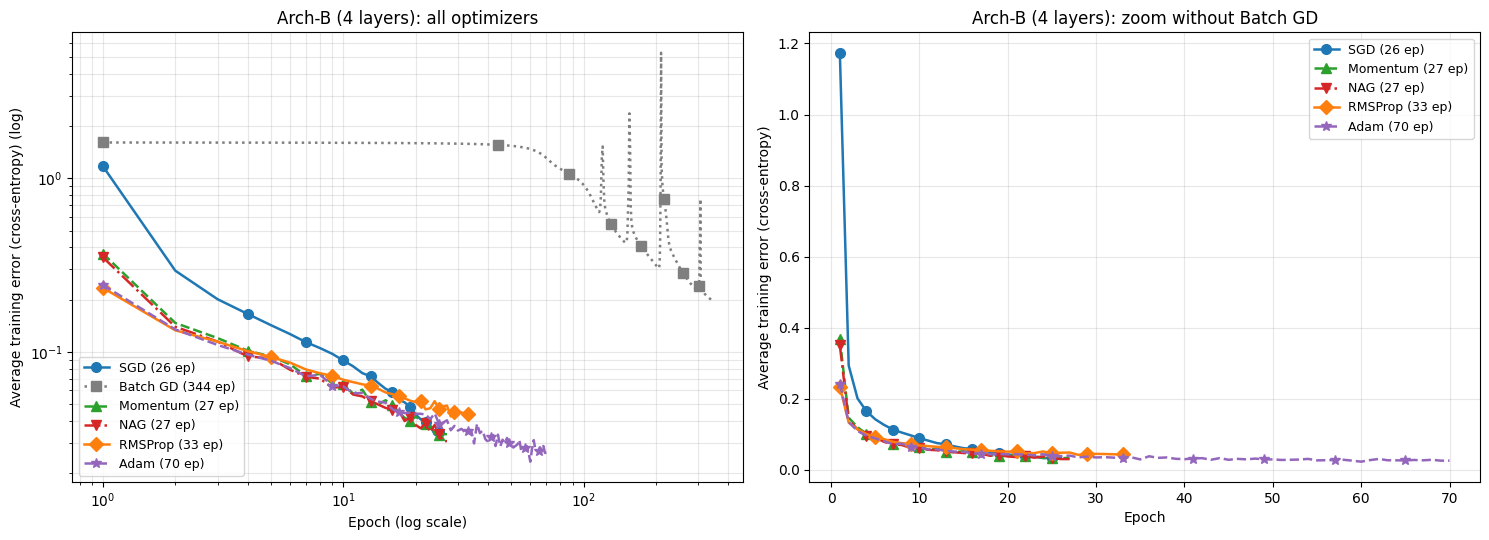

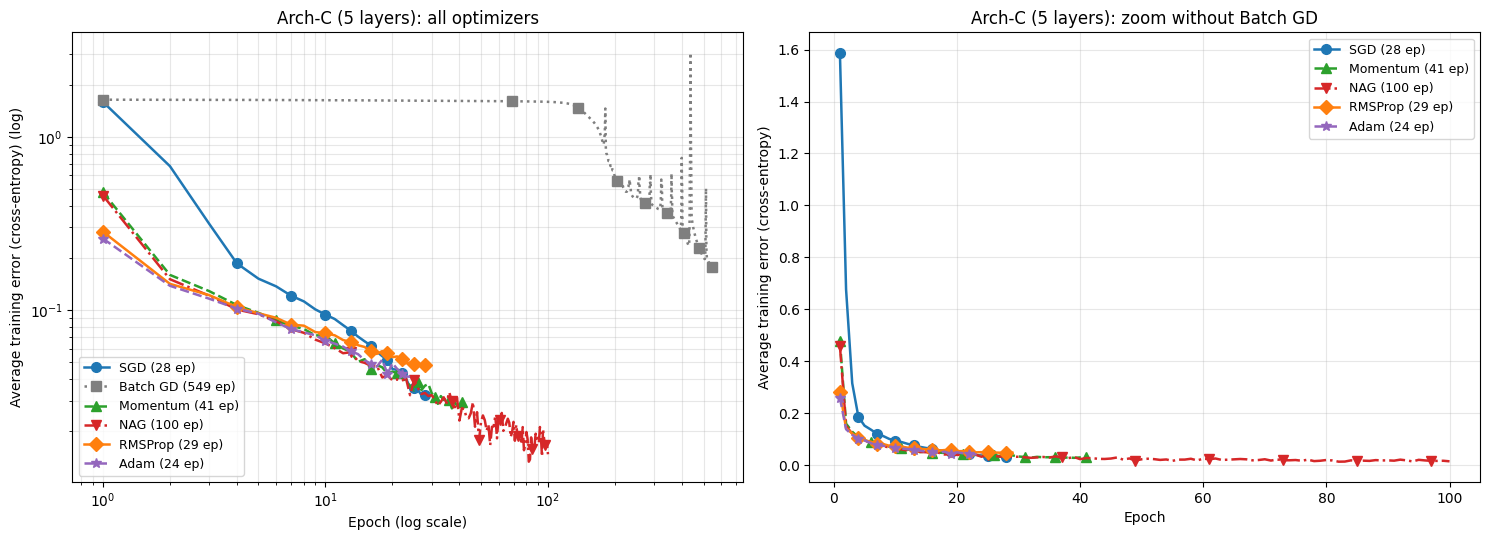

In [46]:
styles = {
    "SGD":      dict(color="#1f77b4", linestyle="-",  marker="o"),
    "Batch GD": dict(color="#7f7f7f", linestyle=":",  marker="s"),
    "Momentum": dict(color="#2ca02c", linestyle="--", marker="^"),
    "NAG":      dict(color="#d62728", linestyle="-.", marker="v"),
    "RMSProp":  dict(color="#ff7f0e", linestyle="-",  marker="D"),
    "Adam":     dict(color="#9467bd", linestyle="--", marker="*"),
}

def plot_curves(ax, arch_name, opts, log_x, log_y):
    for opt_name in opts:
        errors = results[arch_name][opt_name]["epoch_errors"]
        epochs = range(1, len(errors) + 1)
        ax.plot(epochs, errors,
                label=f"{opt_name} ({len(errors)} ep)",
                linewidth=1.8, markersize=7,
                markevery=max(1, len(errors) // 8),   # a few markers per curve, not one per point
                **styles[opt_name])
    if log_x: ax.set_xscale("log")
    if log_y: ax.set_yscale("log")
    ax.set_xlabel("Epoch" + (" (log scale)" if log_x else ""))
    ax.set_ylabel("Average training error (cross-entropy)" + (" (log)" if log_y else ""))
    ax.grid(alpha=0.3, which="both")
    ax.legend(fontsize=9)

for arch_name in architectures:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

    # Left: all six optimizers superimposed (assignment requirement)
    plot_curves(ax1, arch_name, optimizer_names, log_x=True, log_y=True)
    ax1.set_title(f"{arch_name}: all optimizers")

    # Right: zoom on the five batch-size-16 optimizers, linear axes
    plot_curves(ax2, arch_name, [o for o in optimizer_names if o != "Batch GD"],
                log_x=False, log_y=False)
    ax2.set_title(f"{arch_name}: zoom without Batch GD")

    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/error_curves_{arch_key(arch_name)}.png", dpi=150)
    plt.show()

## 11. Best architecture selection (by validation accuracy)



In [47]:
best_arch_name = None
best_opt_name = None
best_val_acc = -1.0

for arch_name in architectures:
    for opt_name in optimizer_names:
        val_acc = results[arch_name][opt_name]["val_accuracy"]
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_arch_name = arch_name
            best_opt_name = opt_name

print(f"Best architecture: {best_arch_name}  ({architectures[best_arch_name]})")
print(f"Best optimizer for that architecture: {best_opt_name}")
print(f"Validation accuracy: {best_val_acc:.2f}%")

Best architecture: Arch-B (4 layers)  ([256, 128, 64, 32])
Best optimizer for that architecture: NAG
Validation accuracy: 97.23%


## 12. Final evaluation of the chosen best architecture: accuracy and confusion matrices

In [48]:
best_model = FCNN(784, architectures[best_arch_name], 5).to(device)
best_model.load_state_dict(trained_states[best_arch_name][best_opt_name])
best_model.eval()


def get_predictions(model, data_loader):
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
    return np.array(all_labels), np.array(all_preds)


train_labels, train_preds = get_predictions(best_model, eval_train_loader)
test_labels, test_preds = get_predictions(best_model, test_loader)

train_accuracy = 100 * accuracy_score(train_labels, train_preds)
test_accuracy = 100 * accuracy_score(test_labels, test_preds)

train_cm = confusion_matrix(train_labels, train_preds)
test_cm = confusion_matrix(test_labels, test_preds)

print(f"Best model: {best_arch_name} + {best_opt_name}")
print(f"Training accuracy: {train_accuracy:.2f}%")
print(f"Test accuracy:     {test_accuracy:.2f}%")

Best model: Arch-B (4 layers) + NAG
Training accuracy: 99.34%
Test accuracy:     97.34%


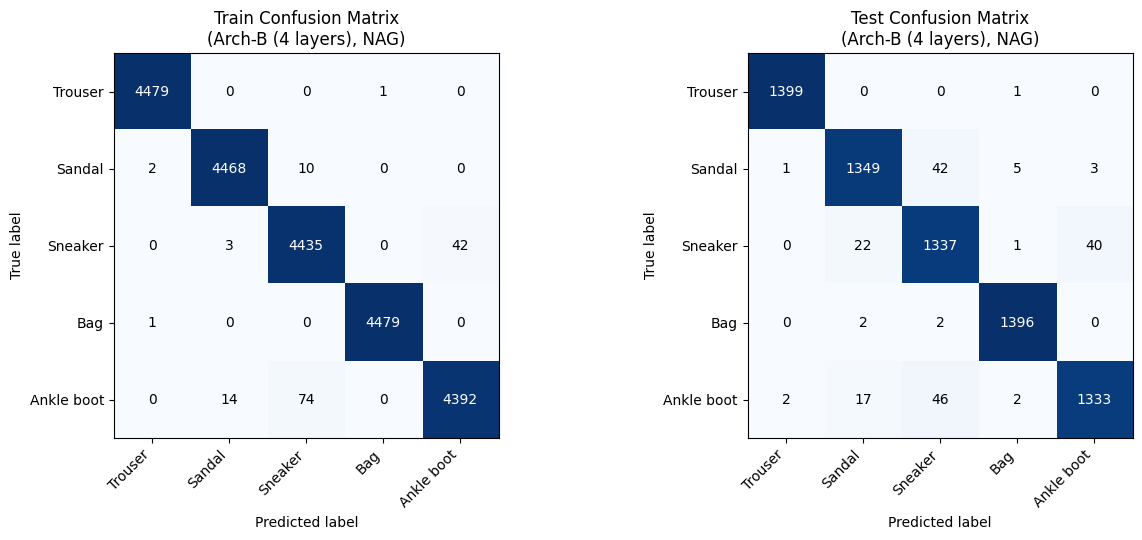

In [49]:
def plot_confusion_matrix(cm, class_names, title, ax):
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], "d"),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")
    return im


fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
plot_confusion_matrix(train_cm, class_names, f"Train Confusion Matrix\n({best_arch_name}, {best_opt_name})", axes[0])
plot_confusion_matrix(test_cm, class_names, f"Test Confusion Matrix\n({best_arch_name}, {best_opt_name})", axes[1])
plt.tight_layout()
plt.show()